In [5]:
# 第一步：导入库+数据加载
import numpy as np
import matplotlib.pyplot as plt
import mne
from mne.time_frequency import tfr_array_morlet
from scipy.signal import welch

# Jupyter适配：设置matplotlib后端
%matplotlib inline
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams['figure.dpi'] = 100  

In [6]:

# ==============================
# 数据路径
DATA_lfp = r"E:\crcns_hc3\ec013.28\ec013.410\ec013.410_LFP.npy"
DATA_lfp_processed = r"E:\crcns_hc3\ec013.28\ec013.410\ec013.410_processed_lfp_625.npy"

# 加载数据
lfp_origin_data = np.load(DATA_lfp)
sfreq_ori = 1250
lfp_processed_data = np.load(DATA_lfp_processed)
sfreq_pro = 625

# 为数据创建MNE信息对象
n_channels_ori = lfp_origin_data.shape[0]
ch_names_ori = [f"ch{i + 1}" for i in range(n_channels_ori)]
ch_types_ori = ["eeg"] * n_channels_ori
info_ori = mne.create_info(ch_names=ch_names_ori, sfreq=sfreq_ori, ch_types=ch_types_ori)

n_channels_pro = lfp_processed_data.shape[0]
ch_names_pro = [f"ch{i + 1}" for i in range(n_channels_pro)]
ch_types_pro = ["eeg"] * n_channels_pro  
info_pro = mne.create_info(ch_names=ch_names_pro, sfreq=sfreq_pro, ch_types=ch_types_pro)

# 创建Raw对象
raw_original = mne.io.RawArray(lfp_origin_data, info_ori)
raw_processed = mne.io.RawArray(lfp_processed_data, info_pro)

# 时频图
# 提取一个通道数据+创建时间轴
sfreq = int(raw_original.info['sfreq'])
orig_data = raw_original.get_data()[2]
proc_data = raw_processed.get_data()[2]
times = np.arange(len(orig_data)) / sfreq

# 取前x秒数据用于绘图（可修改plot_sec调整时长）
plot_sec = 2
plot_n_samples = int(plot_sec * sfreq)
orig_plot = orig_data[:plot_n_samples]
proc_plot = proc_data[:plot_n_samples]
times_plot = times[:plot_n_samples]

Creating RawArray with float64 data, n_channels=65, n_times=1855488
    Range : 0 ... 1855487 =      0.000 ...  1484.390 secs
Ready.
Creating RawArray with float64 data, n_channels=64, n_times=927744
    Range : 0 ... 927743 =      0.000 ...  1484.389 secs
Ready.


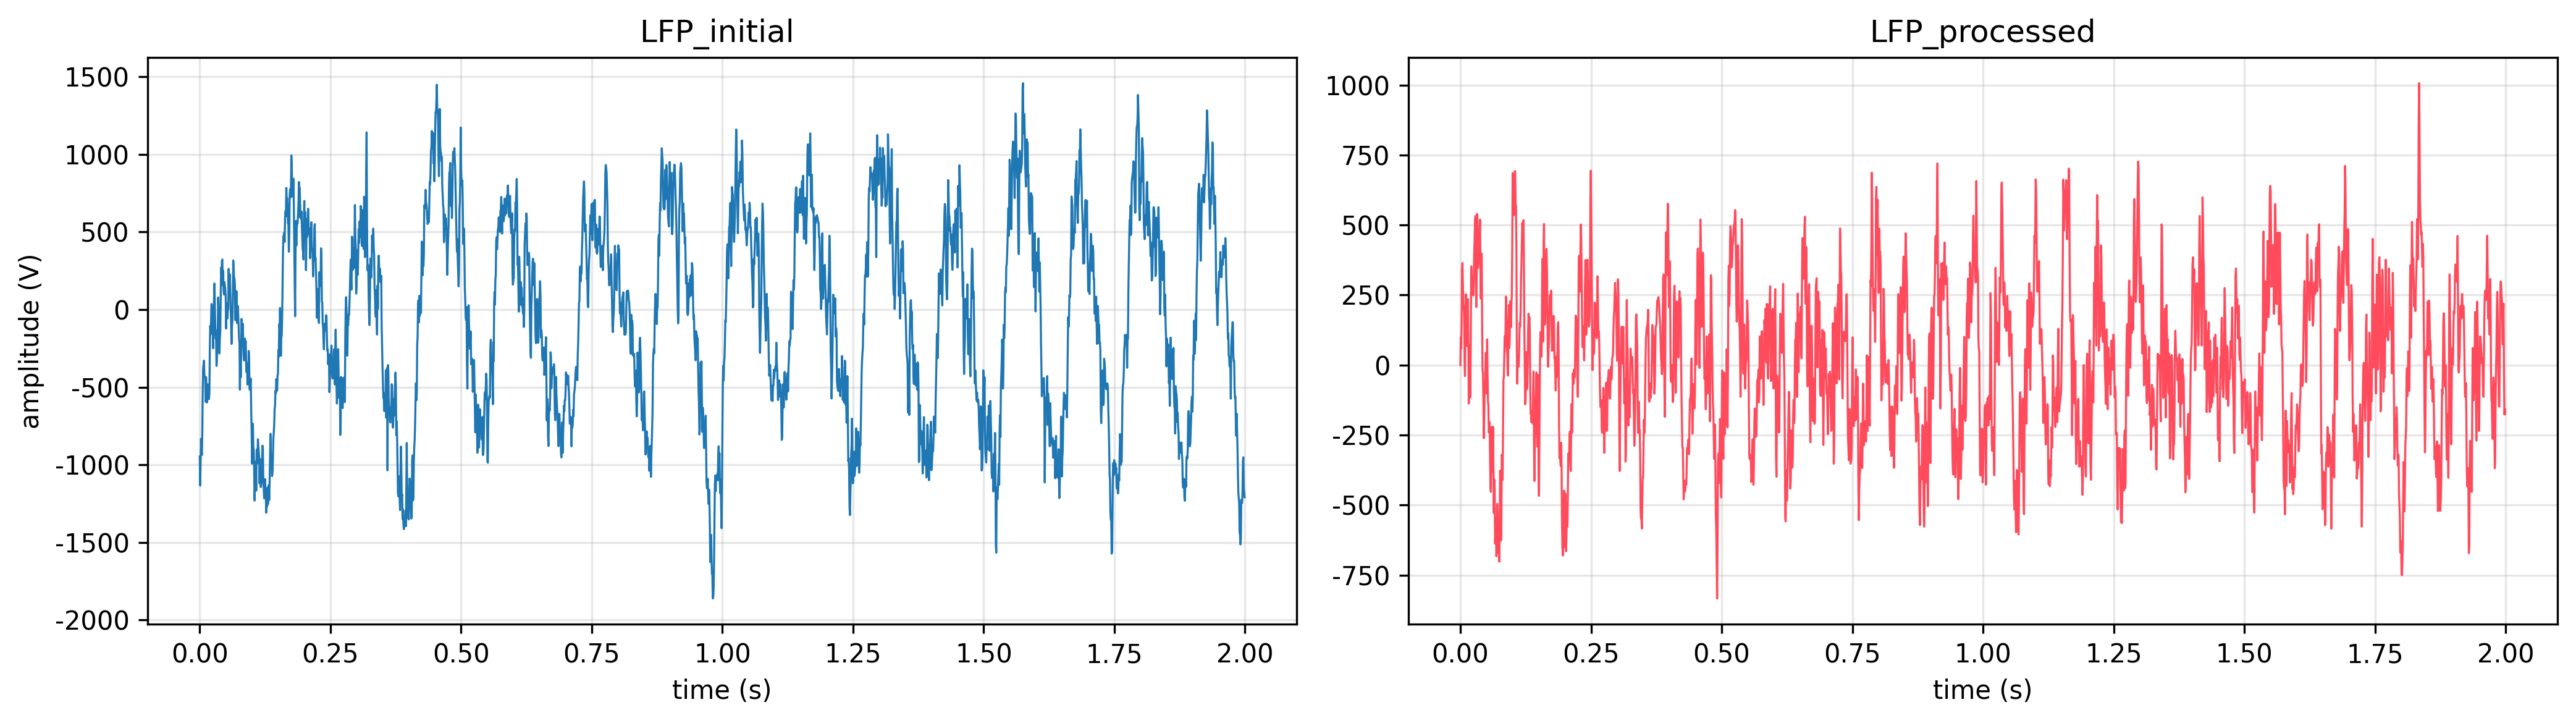

In [16]:
# 第二步：生成第一张图 - 时域波形对比（Jupyter第二个代码块）
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# 原始LFP时域波形
axes[0].plot(times_plot, orig_plot, color='#1f77b4', linewidth=0.8)
axes[0].set_title('LFP_initial ', fontsize=12)
axes[0].set_ylabel('amplitude (V)', fontsize=10)
axes[0].set_xlabel('time (s)', fontsize=10)
axes[0].grid(alpha=0.3)

# 处理后LFP时域波形
axes[1].plot(times_plot, proc_plot, color='#ff4b5c', linewidth=0.8)
axes[1].set_title('LFP_processed', fontsize=12)
axes[1].set_xlabel('time (s)', fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

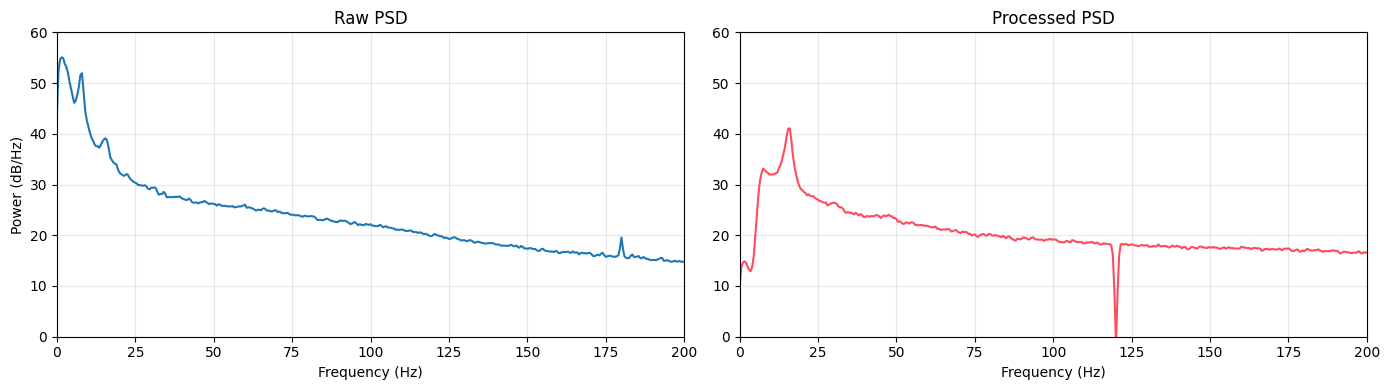

In [8]:
# 第三步：生成第二张图 - PSD功率谱密度对比（Jupyter第三个代码块）
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# 计算PSD
f_orig, pxx_orig = welch(orig_data, sfreq, nperseg=sfreq*2)
f_proc, pxx_proc = welch(proc_data, sfreq, nperseg=sfreq*2)

# 原始PSD
axes[0].plot(f_orig, 10*np.log10(pxx_orig), color='#1f77b4')
axes[0].set_title('Raw PSD', fontsize=12)
axes[0].set_ylabel('Power (dB/Hz)', fontsize=10)
axes[0].set_xlabel('Frequency (Hz)', fontsize=10)
axes[0].set_xlim(0, 200)
axes[0].set_ylim(0, 60)
axes[0].grid(alpha=0.3)

# Processed PSD
axes[1].plot(f_proc, 10*np.log10(pxx_proc), color='#ff4b5c')
axes[1].set_title('Processed PSD', fontsize=12)
axes[1].set_xlabel('Frequency (Hz)', fontsize=10)
axes[1].set_xlim(0, 200)
axes[1].set_ylim(0, 60)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

原始数据在180Hz左右的高频噪声被清除

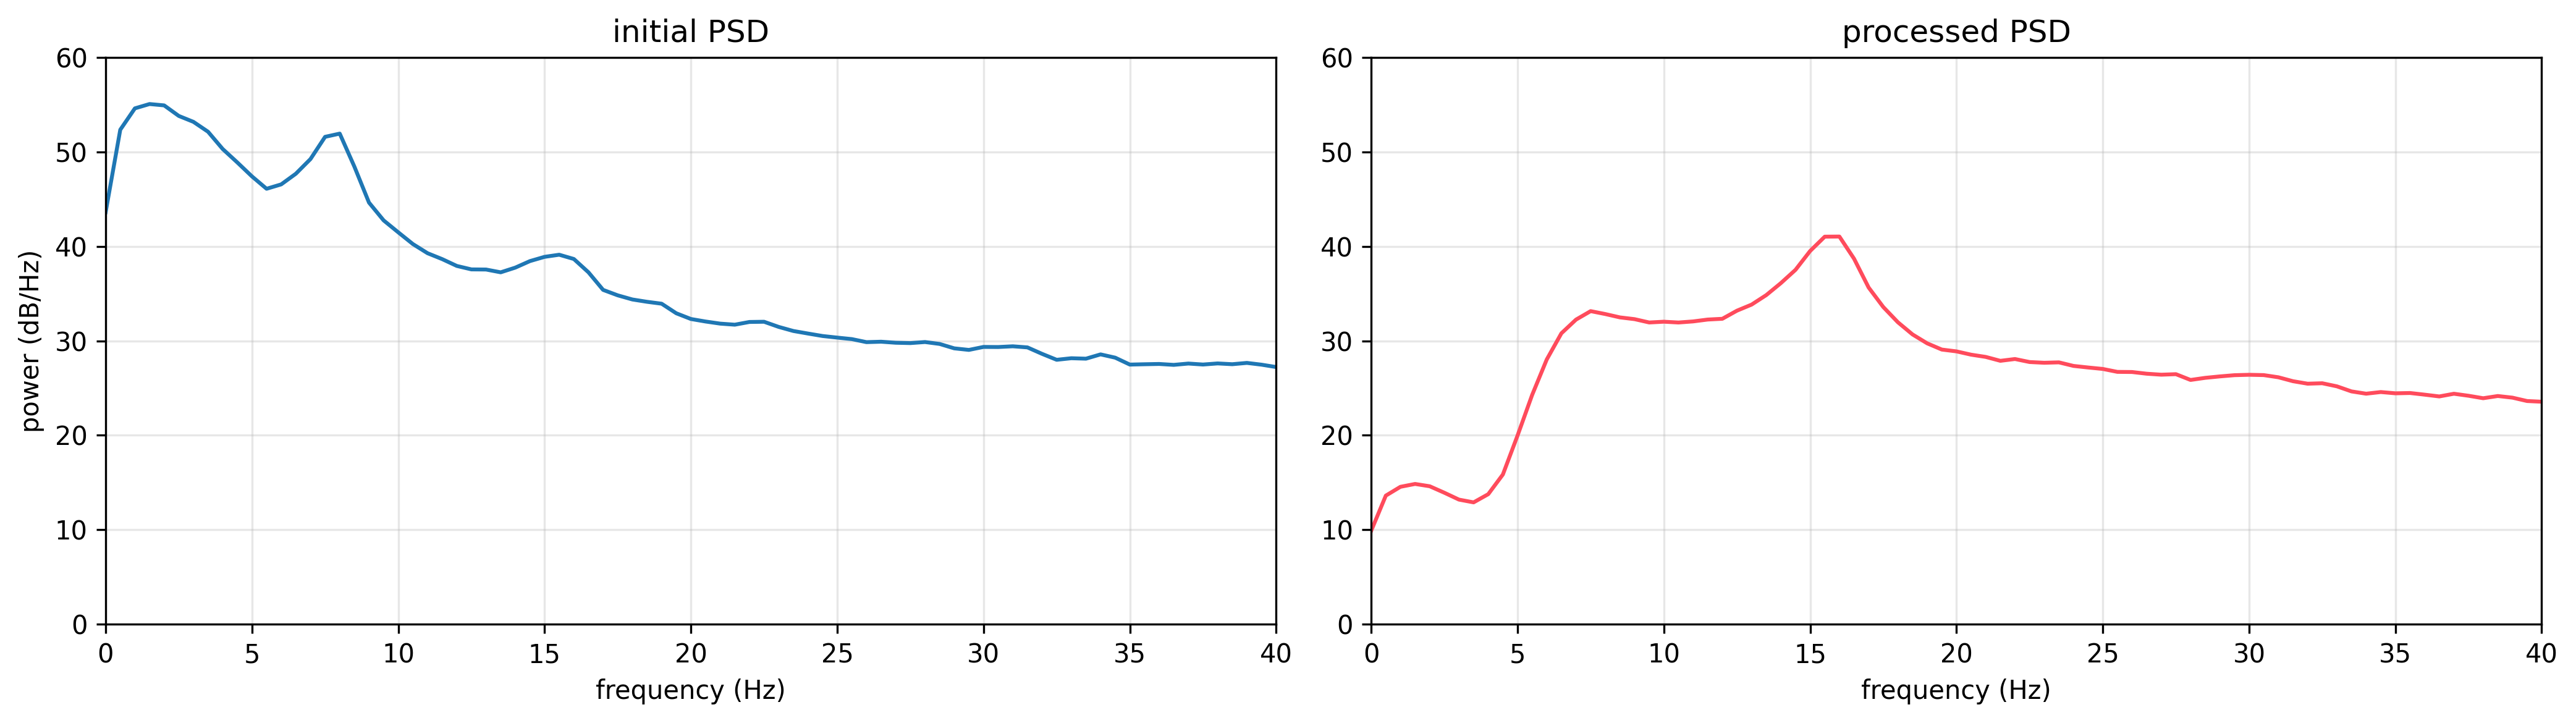

In [7]:
# 第三步：生成第二张图 - PSD功率谱密度对比（缩小范围看0-40Hz）
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
x_max = 40
# 计算PSD
f_orig, pxx_orig = welch(orig_data, sfreq, nperseg=sfreq*2)
f_proc, pxx_proc = welch(proc_data, sfreq, nperseg=sfreq*2)

# 原始PSD
axes[0].plot(f_orig, 10*np.log10(pxx_orig), color='#1f77b4')
axes[0].set_title('initial PSD', fontsize=12)
axes[0].set_ylabel('power (dB/Hz)', fontsize=10)
axes[0].set_xlabel('frequency (Hz)', fontsize=10)
axes[0].set_xlim(0, x_max)
axes[0].set_ylim(0, 60)
axes[0].grid(alpha=0.3)

# 处理后PSD
axes[1].plot(f_proc, 10*np.log10(pxx_proc), color='#ff4b5c')
axes[1].set_title('processed PSD', fontsize=12)
axes[1].set_xlabel('frequency (Hz)', fontsize=10)
axes[1].set_xlim(0, x_max)
axes[1].set_ylim(0, 60)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

filter带来的的边缘效应

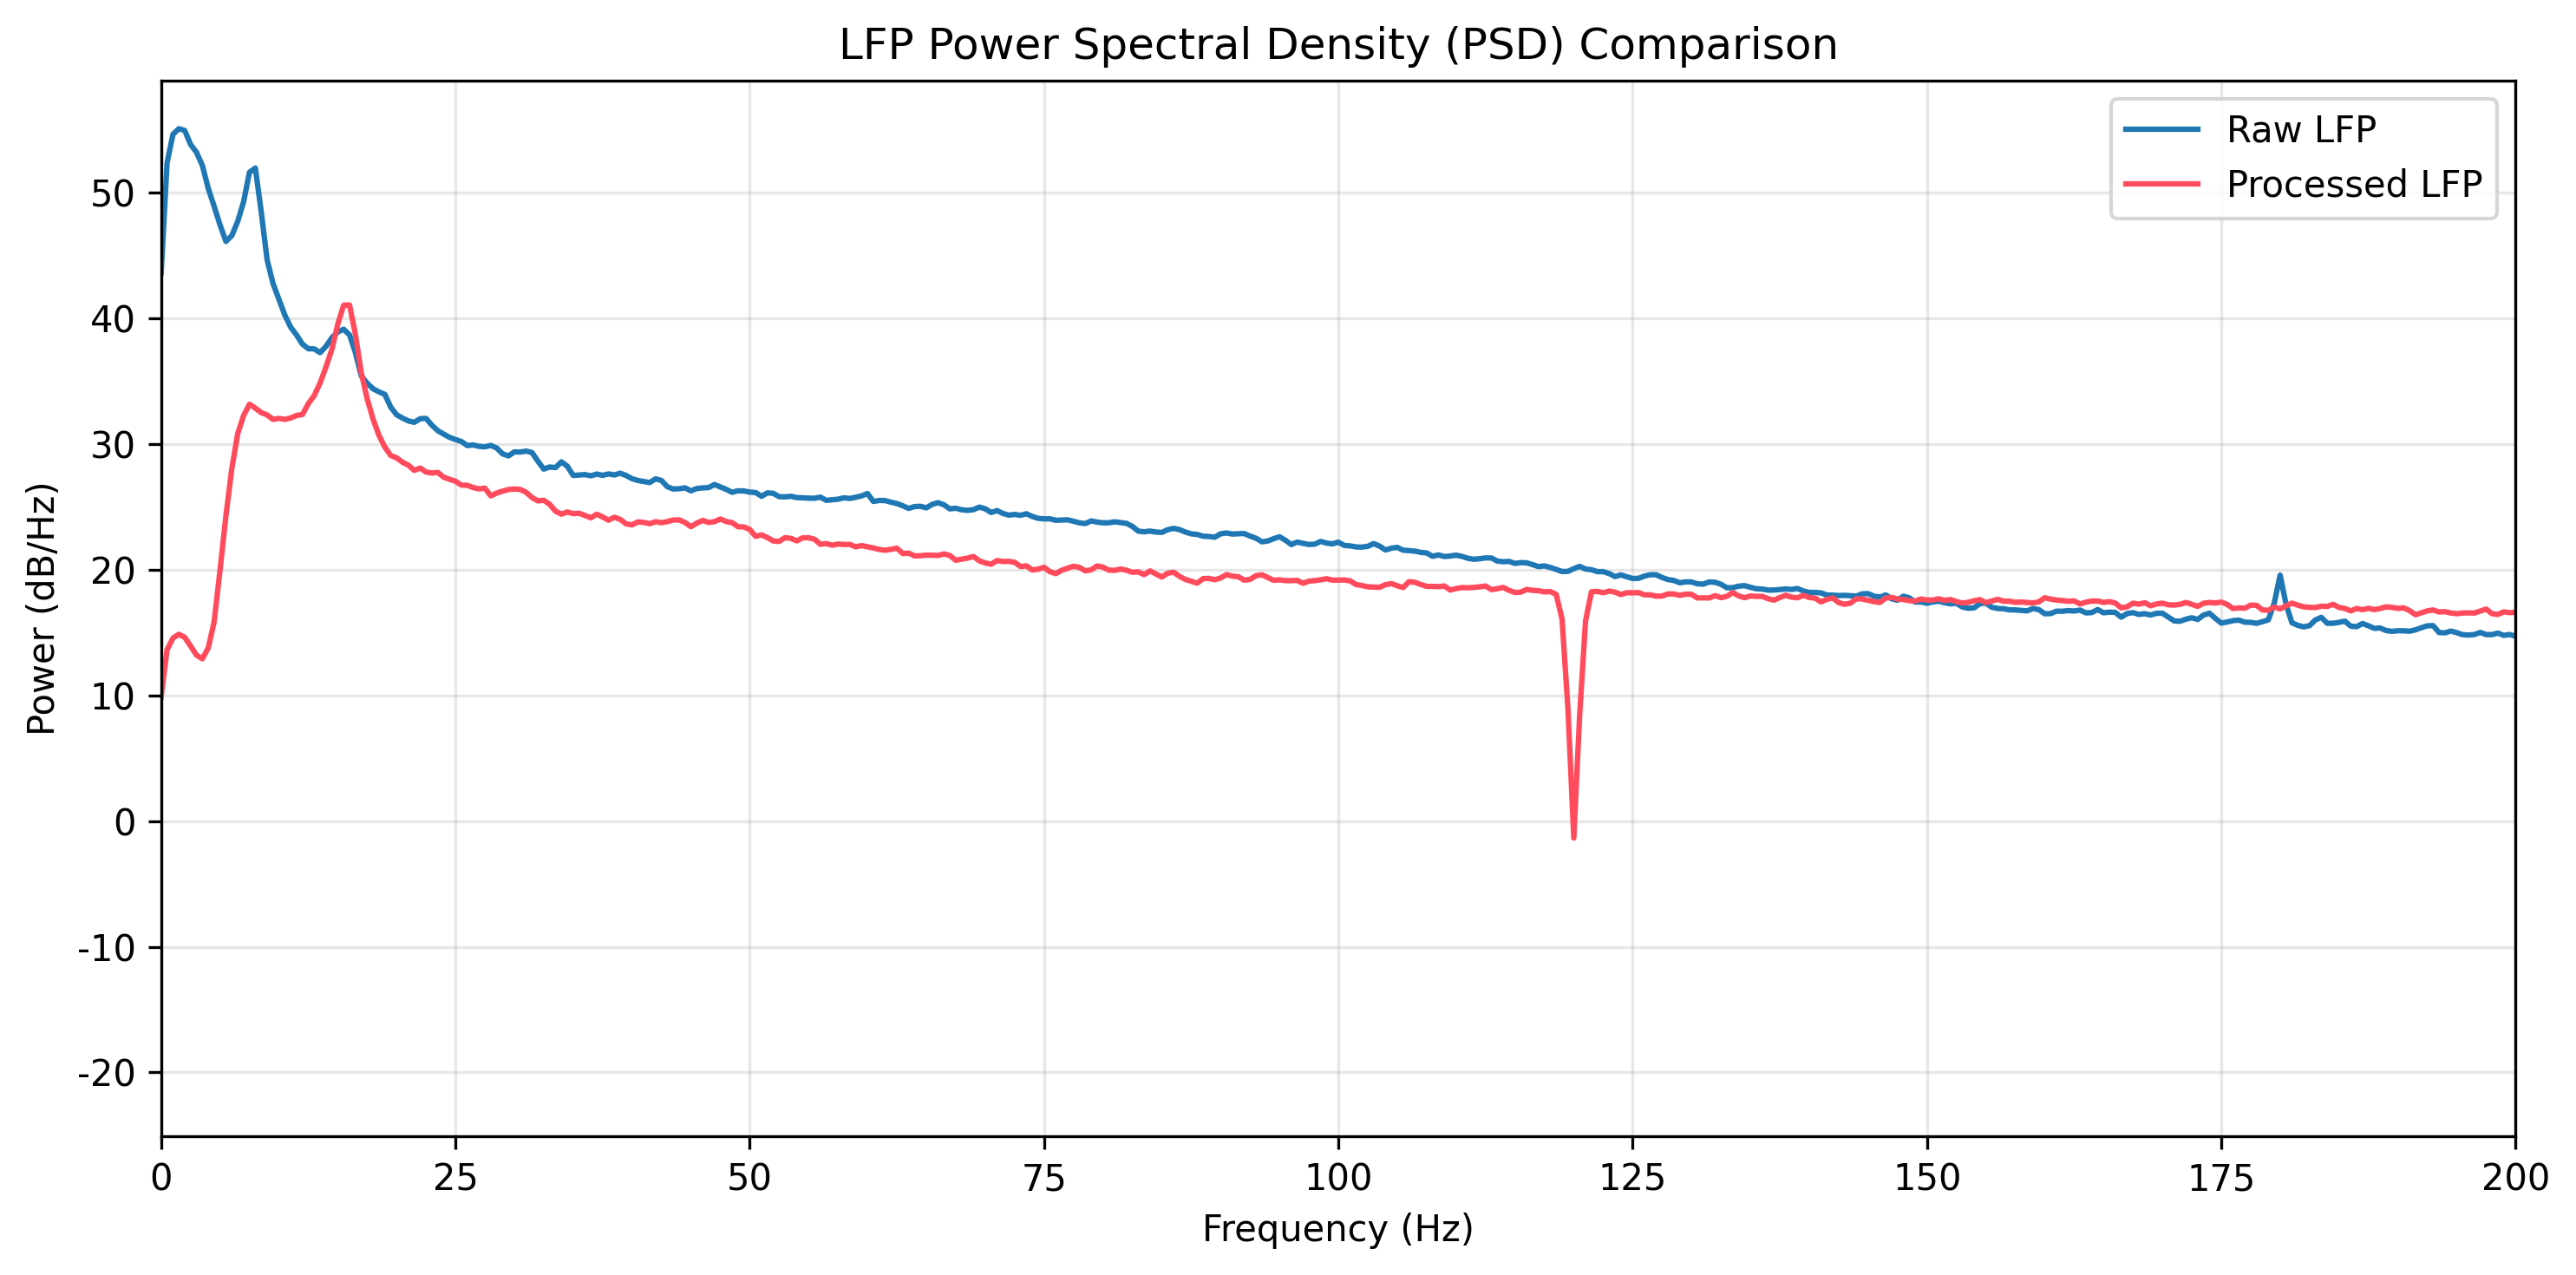

In [11]:
# 新版第二张图：原始信号 & 处理后信号 PSD 画在同一张图中
import matplotlib.pyplot as plt
from scipy.signal import welch

# 计算两者 PSD
f_orig, pxx_orig = welch(orig_data, sfreq, nperseg=sfreq*2)
f_proc, pxx_proc = welch(proc_data, sfreq, nperseg=sfreq*2)

# 画在同一张图
plt.figure(figsize=(10, 5))

# 原始信号（蓝色）
plt.plot(f_orig, 10*np.log10(pxx_orig), 
         color='#1f77b4', linewidth=1.5, label='Raw LFP')

# 处理后信号（红色）
plt.plot(f_proc, 10*np.log10(pxx_proc), 
         color='#ff4b5c', linewidth=1.5, label='Processed LFP')

plt.title('LFP Power Spectral Density (PSD) Comparison', fontsize=12)
plt.xlabel('Frequency (Hz)', fontsize=10)
plt.ylabel('Power (dB/Hz)', fontsize=10)
plt.xlim(0, 200)  # 只看0-100Hz，更清晰
plt.grid(alpha=0.3)
plt.legend()  # 显示图例
plt.tight_layout()
plt.show()

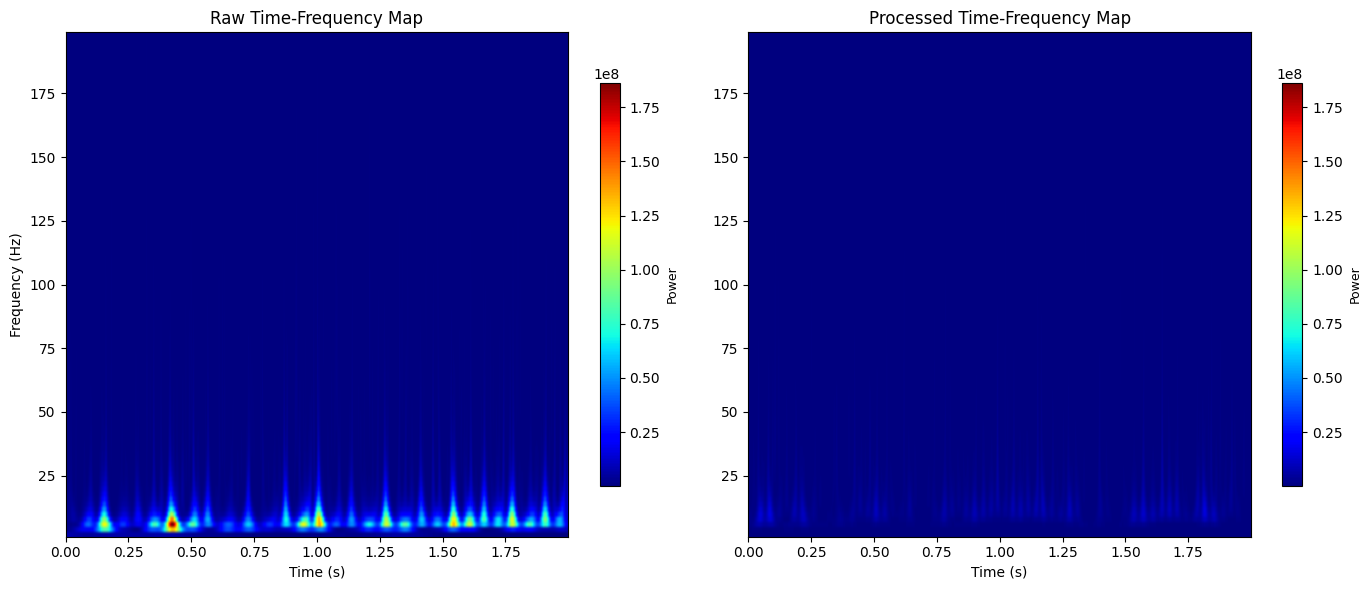

In [10]:
# 第四步：生成第三张图 - 时频图对比（Jupyter第四个代码块）
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 定义频率范围
freqs = np.arange(1, 200, 2)

# 计算原始时频图
orig_s = orig_plot[None, None, :]  # 形状适配：(n_epochs, n_channels, n_times)
tfr_o = tfr_array_morlet(orig_s, sfreq=sfreq, freqs=freqs, n_cycles=1, output='power')[0,0]

# 计算处理后时频图
proc_s = proc_plot[None, None, :]
tfr_p = tfr_array_morlet(proc_s, sfreq=sfreq, freqs=freqs, n_cycles=1, output='power')[0,0]

# 使用同样的colorbar 便于观察
vmin = min(tfr_o.min(), tfr_p.min())
vmax = max(tfr_o.max(), tfr_p.max())

# 绘制原始时频图
im1 = axes[0].imshow(tfr_o, aspect='auto', origin='lower',
                     extent=[times_plot.min(), times_plot.max(), freqs.min(), freqs.max()], 
                     cmap='jet', vmin=vmin, vmax=vmax)
axes[0].set_title('Raw Time-Frequency Map', fontsize=12)
axes[0].set_ylabel('Frequency (Hz)', fontsize=10)
axes[0].set_xlabel('Time (s)', fontsize=10)
# Add colorbar
cbar1 = plt.colorbar(im1, ax=axes[0], shrink=0.8)
cbar1.set_label('Power', fontsize=9)

# Plot processed time-frequency map
im2 = axes[1].imshow(tfr_p, aspect='auto', origin='lower',
                     extent=[times_plot.min(), times_plot.max(), freqs.min(), freqs.max()], 
                     cmap='jet', vmin=vmin, vmax=vmax)
axes[1].set_title('Processed Time-Frequency Map', fontsize=12)
axes[1].set_xlabel('Time (s)', fontsize=10)
# Add colorbar
cbar2 = plt.colorbar(im2, ax=axes[1], shrink=0.8)
cbar2.set_label('Power', fontsize=9)

plt.tight_layout()
plt.show()

使用相同 color scale 进行对比后可见，经过带通滤波 + CAR 等预处理后，LFP 时频图的背景噪声显著降低，垂直伪迹强度减弱，而主要的瞬态高功率事件得以保留，整体信噪比得到明显改善。这为后续的振荡分析和 Spike-LFP 耦合分析提供了高质量的输入信号。